In [184]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sty.mplstyle')

from importlib import reload

import shells as sh
reload(sh)

<module 'shells' from '/home/g/work/LongRange/Shells/shells.py'>

In [129]:
!mkdir plots

In [185]:
N = 10_000

shells = sh.Shells()
shells.initialise(N, Rmin=1e-4)

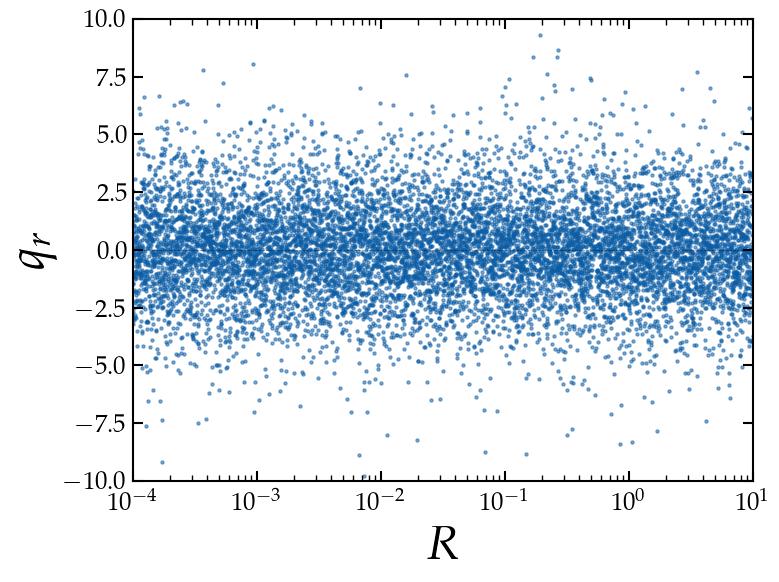

In [186]:
fig = shells.phase_space()

In [190]:
# i = 0

# for i in range(100):
#     shells.step(0.0001)
#     fig = shells.phase_space()
#     plt.savefig('plots/frame_%.3d.png'%i)

In [69]:
# theta = np.linspace(0, 2 * np.pi, 100)

# fig, ax = plt.subplots(figsize=(13,13))


# for i in range(N):
#     r = shells.R[i]
#     x = r * np.cos(theta)
#     y = r * np.sin(theta)
#     plt.plot(x, y, c='k')


# # ax.set_xlim(-1.5, 1.5)
# # ax.set_ylim(-1.5, 1.5)

# ax.set_aspect('equal')
# # plt.xscale('log')
# # plt.yscale('log')
# plt.legend()
# plt.show()

In [124]:
shells.step(0.0001)

In [ ]:
for i

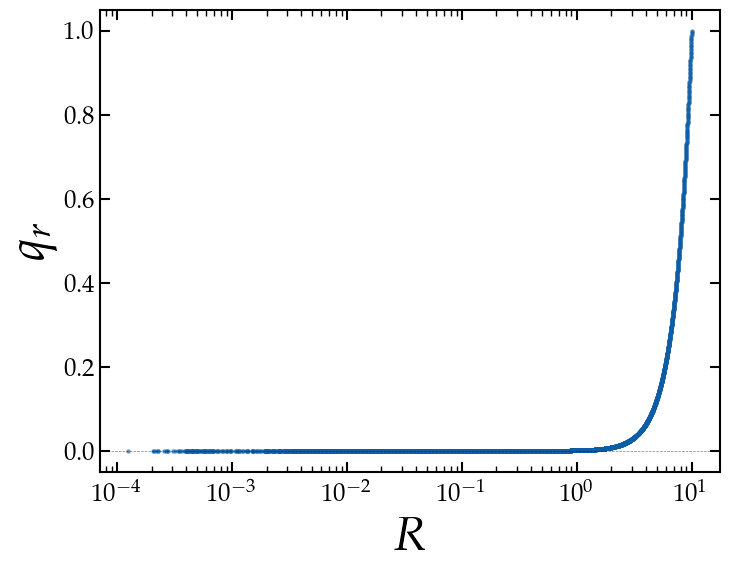

In [189]:
plt.figure(figsize=(8,6))
plt.scatter(shells.R, shells.w, s=5, alpha=0.5)
plt.xlabel(r"$R$")
plt.ylabel(r"$q_r$")
plt.xscale('log')
#plt.ylim(-10, 10)
plt.axhline(0, color='k', lw=0.5, ls='--', alpha=0.5)
plt.show()

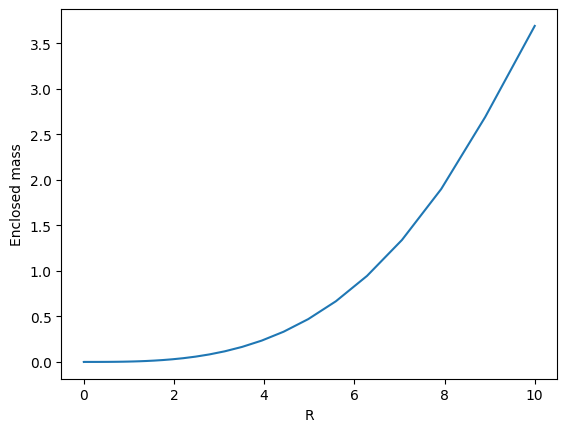

In [86]:
## Mass profile evolution

shells.sort()
Menc = np.cumsum(shells.w)

plt.plot(shells.R, Menc)
plt.xlabel("R")
plt.ylabel("Enclosed mass")
plt.show()

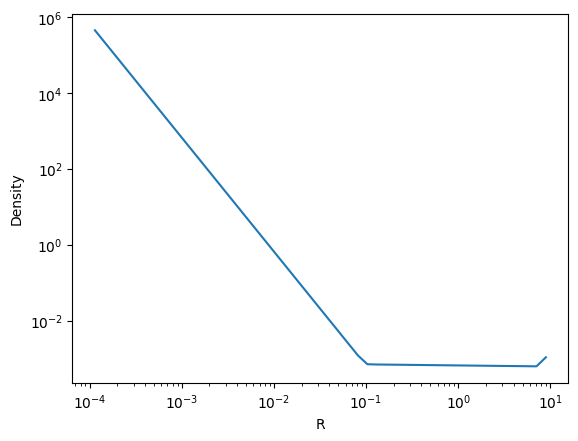

In [87]:
## Densirty profiles

bins = np.logspace(np.log10(shells.R.min()+1e-6),
                   np.log10(shells.R.max()), 50)

hist, edges = np.histogram(shells.R, bins=bins, weights=shells.w)

r_mid = 0.5*(edges[1:] + edges[:-1])
volume = 4/3*np.pi*(edges[1:]**3 - edges[:-1]**3)

rho = hist / volume

plt.loglog(r_mid, rho)
plt.xlabel("R")
plt.ylabel("Density")
plt.show()

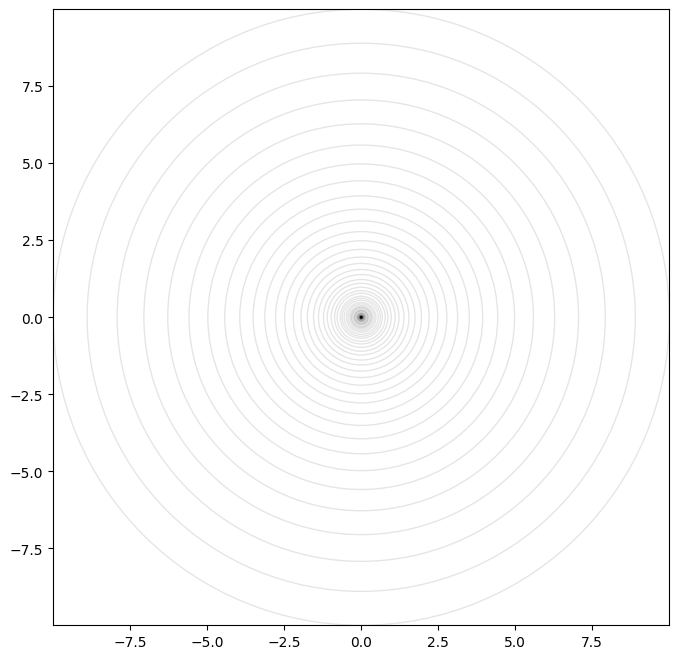

In [83]:
##Circles



from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8,8))

for r in shells.R:
    circle = Circle((0,0), r, fill=False, color='k', alpha=0.1)
    ax.add_patch(circle)

ax.set_xlim(-shells.R.max(), shells.R.max())
ax.set_ylim(-shells.R.max(), shells.R.max())
ax.set_aspect('equal')
plt.show()

In [64]:
%%time
shells.initialise(N, Rmin=1e-4)

CPU times: user 13.9 ms, sys: 999 µs, total: 14.9 ms
Wall time: 14 ms


In [63]:
%%time
solver = sh.ForceSolver(shells)
force = solver.computeF(include_self=False)

CPU times: user 2.5 ms, sys: 37 µs, total: 2.54 ms
Wall time: 1.76 ms


In [58]:
%%time
shells.step(0.001)

CPU times: user 5.38 ms, sys: 975 µs, total: 6.35 ms
Wall time: 5.87 ms


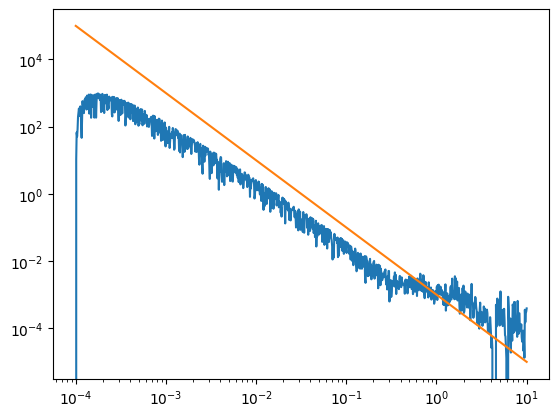

In [46]:
s = 0

plt.loglog(solver.R[s:], force[s:])
plt.loglog(solver.R[s:], 1e-3*solver.R[s:]**(-2))

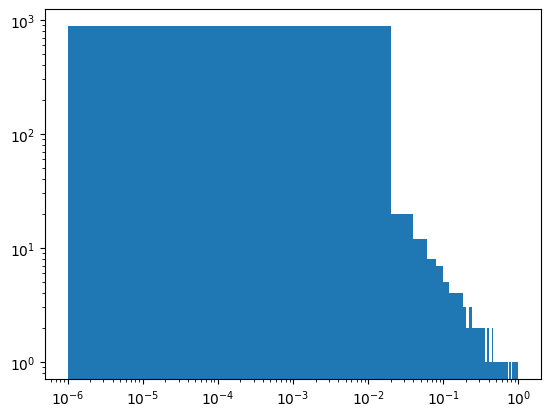

In [54]:
plt.hist(shells.w, bins=50, log=True)
plt.xscale('log')
plt.show()